# Retail Sales Dashboard

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Retail_Sales.xlsx')
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

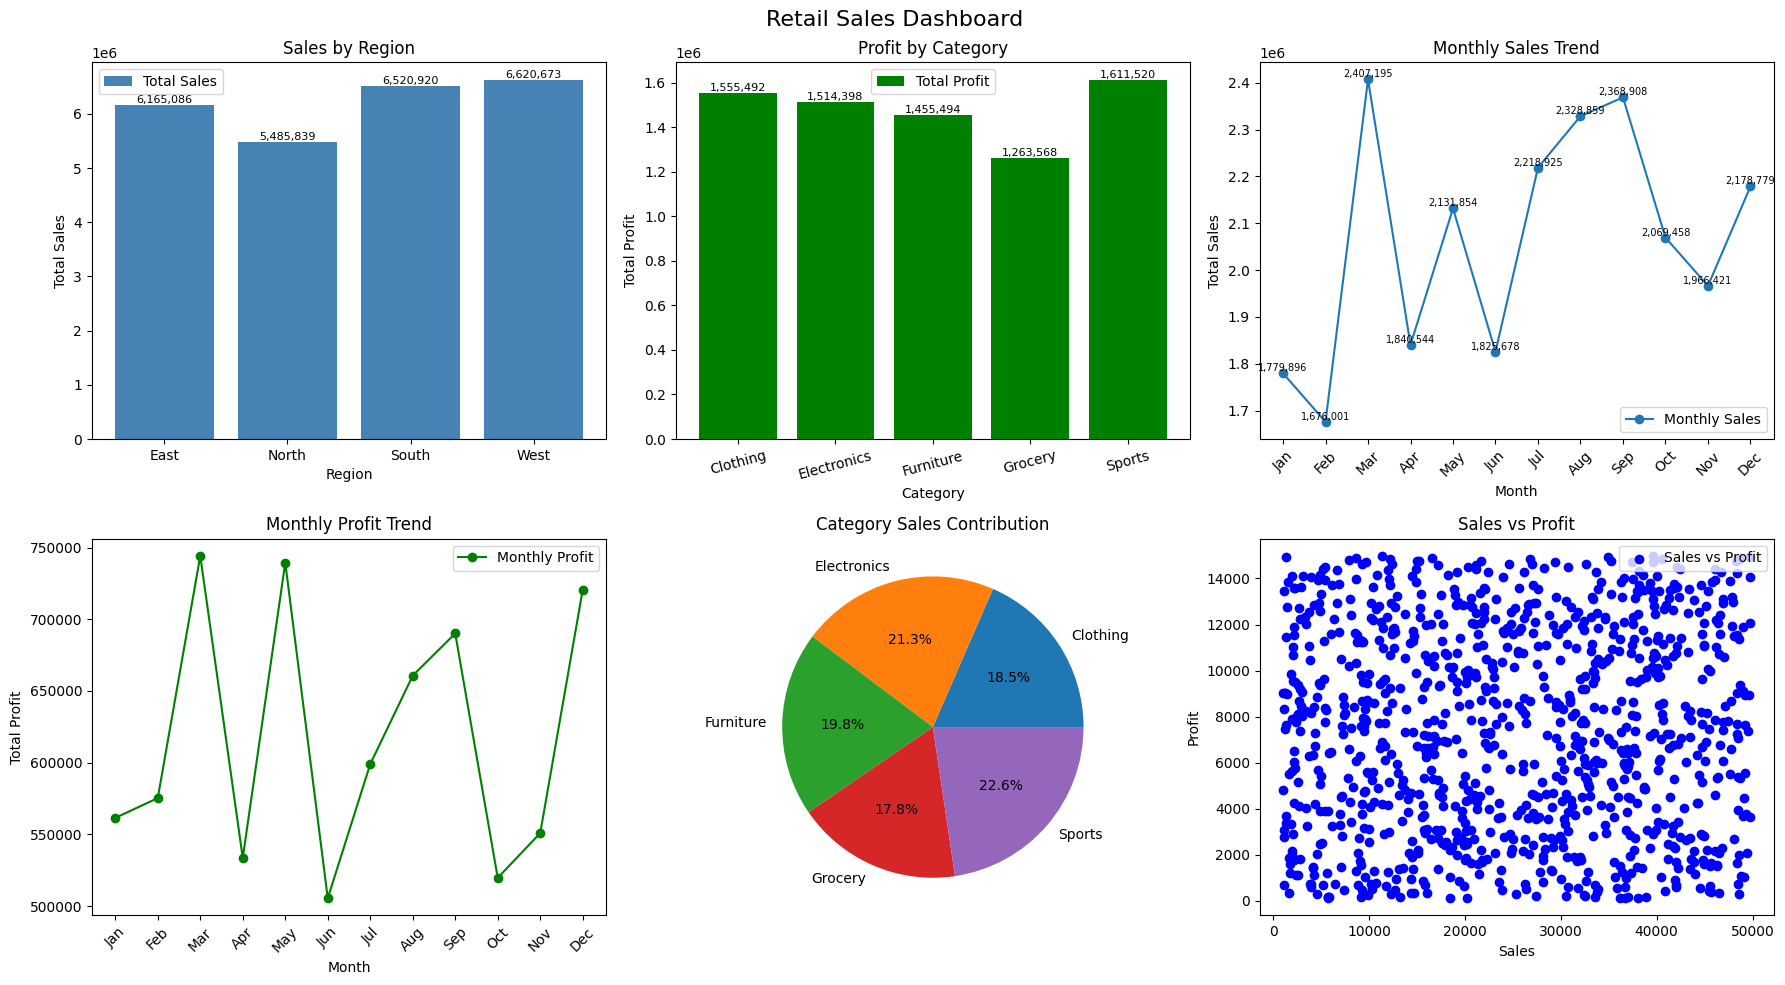

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Retail Sales Dashboard', fontsize=16)

# Graph 1: Sales by Region
region_sales = df.groupby('Region')['Sales'].sum()
axes[0, 0].bar(region_sales.index, region_sales.values, color='steelblue', label='Total Sales')
for p in axes[0, 0].patches:
    axes[0, 0].text(p.get_x() + p.get_width()/2, p.get_height(), f'{int(p.get_height()):,}', ha='center', va='bottom', fontsize=8)
axes[0, 0].set_title('Sales by Region')
axes[0, 0].set_xlabel('Region')
axes[0, 0].set_ylabel('Total Sales')
axes[0, 0].legend()

# Graph 2: Profit by Category
cat_profit = df.groupby('Product_Category')['Profit'].sum()
axes[0, 1].bar(cat_profit.index, cat_profit.values, color='green', label='Total Profit')
for p in axes[0, 1].patches:
    axes[0, 1].text(p.get_x() + p.get_width()/2, p.get_height(), f'{int(p.get_height()):,}', ha='center', va='bottom', fontsize=8)
axes[0, 1].set_title('Profit by Category')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Total Profit')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend()

# Graph 3: Monthly Sales Trend
monthly_sales = df.groupby('Month_Name')['Sales'].sum().reindex(month_order)
axes[0, 2].plot(monthly_sales.index, monthly_sales.values, marker='o', label='Monthly Sales')
for i, v in enumerate(monthly_sales.values):
    axes[0, 2].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=7)
axes[0, 2].set_title('Monthly Sales Trend')
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('Total Sales')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].legend()

# Graph 4: Monthly Profit Trend
monthly_profit = df.groupby('Month_Name')['Profit'].sum().reindex(month_order)
axes[1, 0].plot(monthly_profit.index, monthly_profit.values, marker='o', color='green', label='Monthly Profit')
axes[1, 0].set_title('Monthly Profit Trend')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Profit')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()

# Graph 5: Category Sales Contribution
cat_sales = df.groupby('Product_Category')['Sales'].sum()
axes[1, 1].pie(cat_sales, labels=cat_sales.index, autopct='%1.1f%%')
axes[1, 1].set_title('Category Sales Contribution')

# Graph 6: Sales vs Profit
axes[1, 2].scatter(df['Sales'], df['Profit'], color='blue', label='Sales vs Profit')
axes[1, 2].set_title('Sales vs Profit')
axes[1, 2].set_xlabel('Sales')
axes[1, 2].set_ylabel('Profit')
axes[1, 2].legend()

plt.tight_layout()
plt.show()